# Introduction to Convolutional Neural Networks

In this notebook we will see how to define and use a Convolutional Neural Network (CNN) for clasifying images.

Contrary to the MLPs we have used up to know, where each unit connects to all the units of the previous layer, a unit in a convoutional layer only "sees" a small region of the layer before, and applies a filter - a local operation - on this small region. The key idea is to apply this same filter to the whole image in a grid fashion, which results into a map of activations for this filter. Using many filters, results into a set of activation maps that when stacked together will form the output of the convolutional layer (each activation map corresponding to a "channel").

Typically, convolutions are followed by pooling layers that reduce the dimensionality of our intermedate result, and give us every time a little bit more of viewpoint invariance (at the cost of losing precise information about the location of things).

When dealing with images, our inputs, and all intermediate tensors we produce through convolution layers will be 3-dimensional tensors. And if we vectorise our operations and pass a whole batch of images in a single go, we will be dealing with 4-dimensional tensors. The ordering of the dimensions in pytorch is $(BatchSize \times nChannels \times Height \times Width)$.

After a series of convolutions and pooling operations, we typically want to flaten the images. The flattening operation collapses an array into a 1-dimensional vector. For example, if we have a tensor of $20 \times 5 \times 5$ $(C \times H \times W)$, its flattened version is a 1d vector of $500$ values. Now we can feed these $500$ values into a MLP for classifiying the image.

In [1]:
import torch #should be installed by default in any colab notebook
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# function to count number of parameters
def get_n_params(model):
    np=0
    for p in list(model.parameters()):
        np += p.numel()
    return np

In [2]:
# If this cell fails you need to change the runtime of your colab notebook to GPU
# Go to Runtime -> Change Runtime Type and select GPU
assert torch.cuda.is_available(), "GPU is not enabled"

# use gpu if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data

Before training we need data! For this notebook we will use the FashionMNIST dataset. Which is available in [torchvision](https://pytorch.org/vision/stable/index.html)


In [4]:
train_set = datasets.FashionMNIST("data", train=True, download=True, transform=transforms.Compose([transforms.ToTensor(), transforms.RandomHorizontalFlip()]))
val_set = datasets.FashionMNIST("data", train=False, download=True, transform=transforms.Compose([transforms.ToTensor()]))

train_loader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=512, shuffle=False, num_workers=2)

The images of FashionMNIST are of size $(28 \times 28)$ pixels, and have a single channel - the greyscale one. So they are given as a 2D tensor. You can easily check this:

In [5]:
img = train_set.data[0]
img.shape

torch.Size([28, 28])

# Filters and Convolutional layers

To define a CNN model, similarly to the MLP case, we need to define all the operations and then combine them into the forward pass. Apart from `nn.Linear()` layers, we will now use `nn.Conv2d()` layers, which correspond to 2D convolutions.

To perform a convolution, we need to define the size of our filters, and how many filters to use.

The size of the filter is given by its width and height (which will be equal), and the number of channels which has to be the same as the number of channels of the input it will be applied to. So, if `in_channels` is the number of channels of the input, and `kernel_size` is the width and height of our filter, then our filter will be a tensor of shape $(in\_channels \times kernel\_size \times kernel\_size)$.

The other piece of information needed is how many filters to use. Remember that each filter gives rise to one activation map, which in turn corresponds to one channel in the output. So the number of filters to use is the same as the number of output channels (`out_channels`) we want to have.

Internally, the set of weights that represent all the filters of a convolutional layer is stored as a single 4D tensor of shape (Number of filters, Number of channels, Height, Width), which would be equivalently $(out\_channels \times in\_channels \times kernel\_size \times kernel\_size)$

This is the minimum information needed to define a convolution layer. Unless otherwise specified, this would apply a default padding of zero and stride of 1. Have a look at the documentation for more details on the `nn.Conv2d()` layer.

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html?highlight=conv#torch.nn.Conv2d

Finally, remember the formula to calculate the size of the output $o$ given the input size $n$ the filter size $f$ the padding $p$ and the stride $s$:

$o = {\frac {(n + 2p - f)} s} + 1$

<br>
<span style="color:blue">

**Exercise 1**: Given the following convolutional layer:

`nn.Convd2(in_channels=20, out_channels=128, kernel_size=3)`

What is the shape of the weights and biases of the convolutional layer?

</span>

---
*out_channels* = 128, so we have 128 neurons in the layer

The kernel has a shape 3x3, and will be applied on all 20 channels of the input

Then, the shape of the weights and biases are :
  - Weights : $(128, 20, 3, 3)$
  - Biases : $(128,)$


---

# Our Convolutional Model

Let's define now our first CNN model.

In [6]:
class CNN(nn.Module):
    def __init__(self, n_feature, output_size):
        super(CNN, self).__init__()
        self.n_feature = n_feature
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=n_feature, kernel_size = 5)
        self.conv2 = nn.Conv2d(n_feature, n_feature, kernel_size=5)
        self.fc1 = nn.Linear(n_feature, 50)
        self.fc2 = nn.Linear(50, 10)
        self.maxpool = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.maxpool(x)
        x = x.view(-1, self.n_feature)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

<font color="blue">**Exercise 2**: The model defined above has a shape mismatch problem. Calculate the correct input dimension for `fc1` and change its definition in the `__init__()` method and the call to `x.view()` in the forward pass. </font>

In [7]:
class CNN(nn.Module):
    def __init__(self, n_feature, output_size):
        super(CNN, self).__init__()
        self.n_feature = n_feature
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=n_feature, kernel_size = 5)
        self.conv2 = nn.Conv2d(n_feature, n_feature, kernel_size = 5)
        # We have to change the shape of fc1 : the output size is n_features*4*4
        self.fc1 = nn.Linear(4*4*n_feature, 50)
        self.fc2 = nn.Linear(50, 10)
        self.maxpool = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):     # b, 1, 28, 28
        # We apply the first convolutional layer with a kernel size of 5 : we obtain 24x24 matrices
        x = self.conv1(x)     # b, n_feature, 24, 24
        x = F.relu(x)
        # The maxpool has a kernel size of 2 : the shape of the matrix is divided by 2
        x = self.maxpool(x)   # b, n_feature, 12, 12
        # The same kernel is used : we obtain a 8x8 matrix
        x = self.conv2(x)     # b, n_feature, 8, 8
        x = F.relu(x)
        # Applying the maxpool, again, we divide the shape by 2
        x = self.maxpool(x)   # b, n_feature, 4, 4
        # We change the shape
        x = x.view(-1, self.n_feature*4*4)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

# Hyperparameters

To use our CNN we need to create our model and define our hyperparameters. We will use an output size of 10, as there are 10 classes in FashionMNIST, and we will train with cross entropy loss and stochastic gradient descent.

In [8]:
torch.backends.cudnn.benchmark = True
learning_rate = 1e-2
lambda_l2 = 1e-5
momentum = 0.5
torch.manual_seed(0) # seed for reproductibility

output_size = 10  # there are 10 classes

model = CNN(6, output_size)

print(f"Number of parameters {get_n_params(model)}:")

# move model to gpu if available
model.to(device)

# nn package also has different loss functions.
# we use cross entropy loss for our classification task
criterion = torch.nn.CrossEntropyLoss() # https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss

# we use the optim package to apply
# stochastic gradient descent for our parameter updates
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=lambda_l2) # built-in L2

Number of parameters 6422:


<br>
<span style="color:blue">

**Exercise 3**: What does the line `torch.backends.cudnn.benchmark = True` do? How will it affect our runtime if the size of the input images vary a lot?</font>

> Hint: Have a look at https://pytorch.org/docs/stable/backends.html

</span>

---

Using this line, *torch* will search for the best algorithm to solve the problem faster. Then, the runtime may vary less when the input's size vary a lot.

---

# Training and Validation

We should also define our training and validation loops. These are similar to previous notebooks.

In [10]:
@torch.no_grad()  # prevent this function from computing gradients
def validate(criterion, model, loader):

    val_loss = 0
    correct = 0

    # We use eval mode
    model.eval()

    for data, target in loader:
        # We work with the GPU
        data, target = data.to(device), target.to(device)

        # We compute the loss
        output = model(data)
        loss = criterion(output, target)
        val_loss += loss.item()
        # We get the output class obtained
        pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
        correct += pred.eq(target.view_as(pred)).sum().item()

    val_loss /= len(loader.dataset)
    accuracy = 100. * correct / len(loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        val_loss, correct, len(loader.dataset), accuracy))


    return val_loss


def train(epoch, criterion, model, optimizer, loader):

    total_loss = 0.0
    # Train mode
    model.train()

    for batch_idx, (data, target) in enumerate(loader):
        # Make the zero grad
        optimizer.zero_grad()
        # We work with the GPU
        data, target = data.to(device), target.to(device)
        # We apply the model (forward pass)
        output = model(data)
        loss = criterion(output, target)
        # Backward pass
        loss.backward()
        optimizer.step()

        # Each 100 batch, we print the loss for the current epoch
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(loader.dataset),
                100. * batch_idx / len(loader), loss.item()))


        total_loss += loss.item()  #.item() is very important here? Why?

    return total_loss / len(loader.dataset)

## Run Training

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.313606
Train Epoch: 0 [25600/60000 (43%)]	Loss: 2.296756
Train Epoch: 0 [51200/60000 (85%)]	Loss: 2.240676

Test set: Average loss: 0.0043, Accuracy: 2388/10000 (24%)



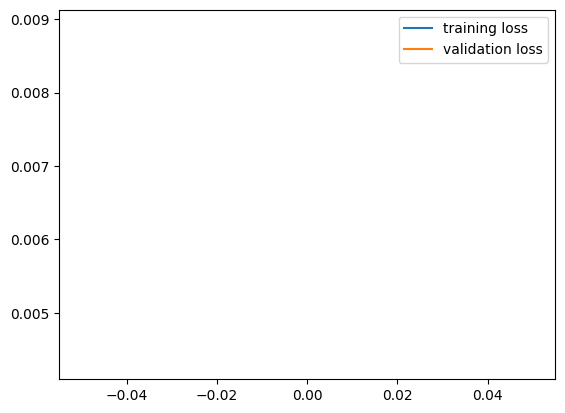

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.154281
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.117178
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.013618

Test set: Average loss: 0.0023, Accuracy: 5841/10000 (58%)



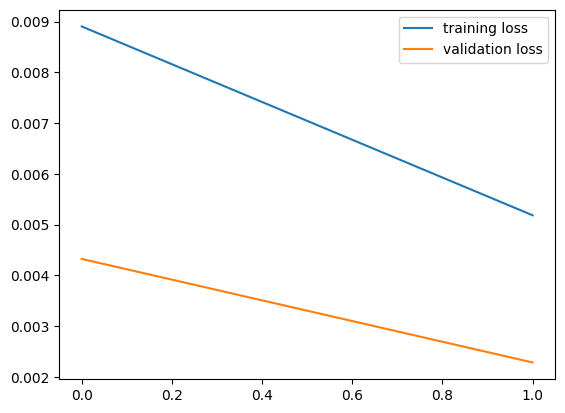

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.996525
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.886214
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.868167

Test set: Average loss: 0.0017, Accuracy: 6542/10000 (65%)



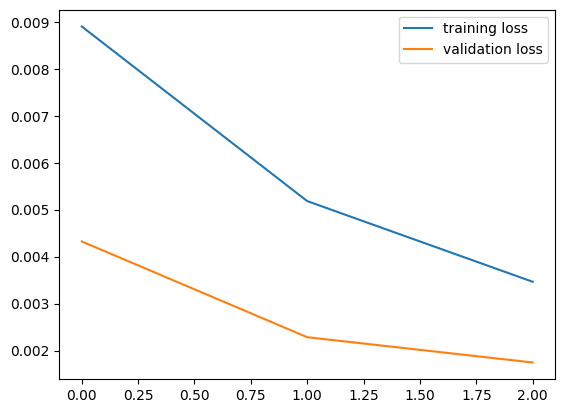

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.882826
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.811700
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.792915

Test set: Average loss: 0.0017, Accuracy: 6813/10000 (68%)



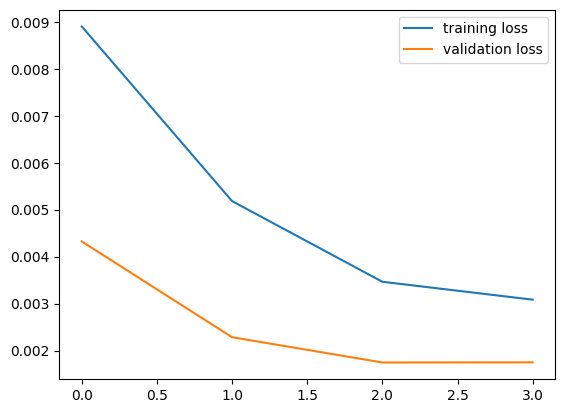

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.921585
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.707741
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.748126

Test set: Average loss: 0.0014, Accuracy: 7212/10000 (72%)



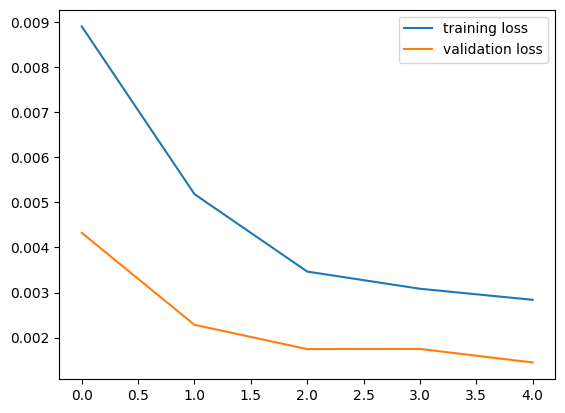

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.686059
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.675310
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.666471

Test set: Average loss: 0.0015, Accuracy: 7203/10000 (72%)



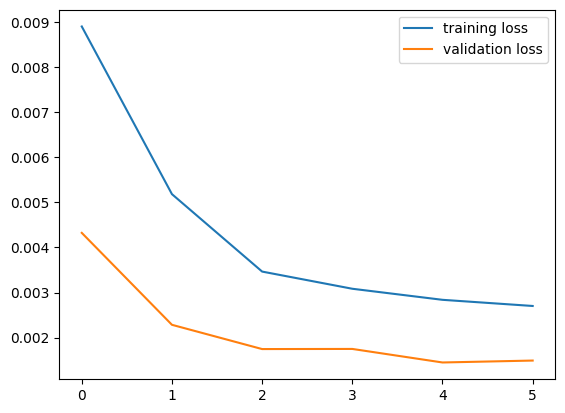

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.821187
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.764208
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.714701

Test set: Average loss: 0.0013, Accuracy: 7484/10000 (75%)



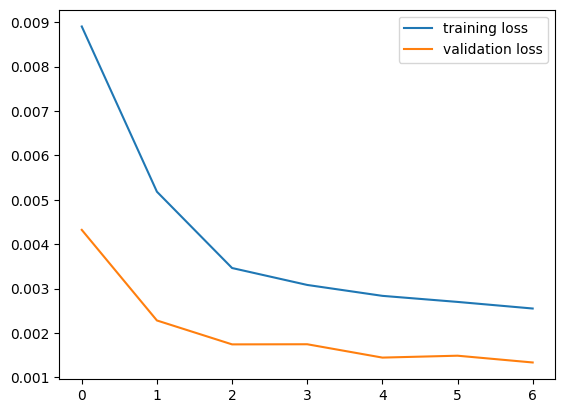

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.622326
Train Epoch: 7 [25600/60000 (43%)]	Loss: 0.536521
Train Epoch: 7 [51200/60000 (85%)]	Loss: 0.611315

Test set: Average loss: 0.0013, Accuracy: 7579/10000 (76%)



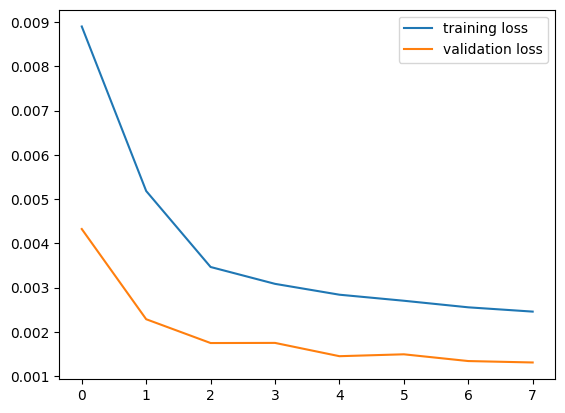

Train Epoch: 8 [0/60000 (0%)]	Loss: 0.645713
Train Epoch: 8 [25600/60000 (43%)]	Loss: 0.577494
Train Epoch: 8 [51200/60000 (85%)]	Loss: 0.612339

Test set: Average loss: 0.0012, Accuracy: 7701/10000 (77%)



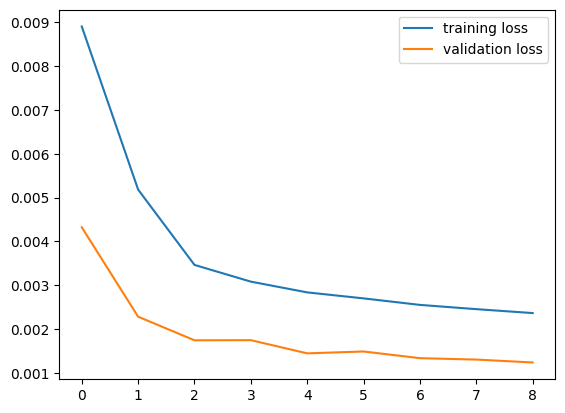

Train Epoch: 9 [0/60000 (0%)]	Loss: 0.645925
Train Epoch: 9 [25600/60000 (43%)]	Loss: 0.616158
Train Epoch: 9 [51200/60000 (85%)]	Loss: 0.476281

Test set: Average loss: 0.0012, Accuracy: 7750/10000 (78%)



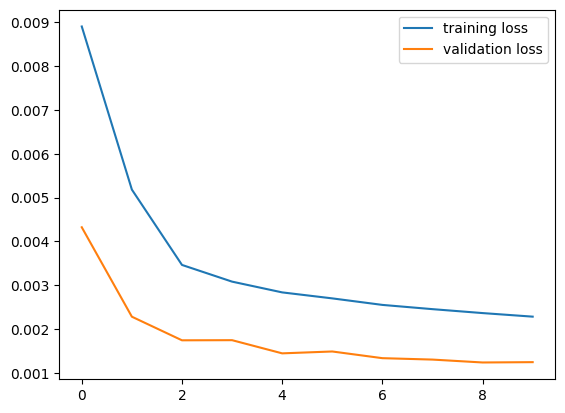

In [11]:
losses = {"train": [], "val": []}

for epoch in range(10):

    train_loss = train(epoch, criterion, model, optimizer, train_loader)
    val_loss = validate(criterion, model, val_loader)
    losses["train"].append(train_loss)
    losses["val"].append(val_loss)

    plt.plot(losses["train"], label="training loss")
    plt.plot(losses["val"], label="validation loss")

    plt.legend()
    plt.pause(0.000001)
    plt.show()

It may also be useful to visualize some qualitative examples of classification

Correctly predicted: 79.4921875%


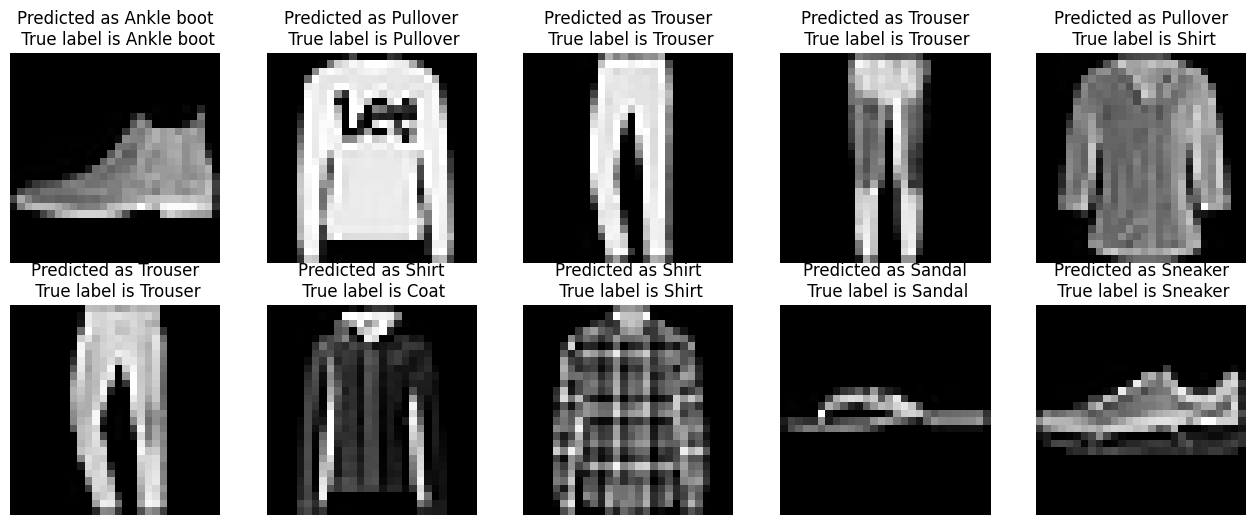

In [12]:
with torch.no_grad():

    data, target = next(iter(val_loader))
    data, target = data.to(device), target.to(device)

    output = model(data)
    predictions = np.argmax(output.cpu().numpy(), axis=1).tolist()
    true = target.cpu().numpy().tolist()

    plt.figure(figsize=(16, 6))

    print("Correctly predicted: {}%".format(100*sum(p == t for p, t in zip(predictions, true))/len(predictions)) )

    for i in range(10):
        plt.subplot(2, 5, i + 1)
        image = data[i,...].cpu().numpy().reshape((28,28))
        plt.imshow(image, cmap="gray")
        plt.axis('off')
        plt.title('Predicted as {}\n True label is {}'.format(val_set.classes[predictions[i]], val_set.classes[true[i]], ))

As we can see, the accuracy is quite good, even with a simple model. Also, as we can see above, only 2 objects have been wrongly classified on our printing batch.

<br>
<span style="color:blue">
    
**Exercise 4**: Now repeat the same process, but flip the images horizontally before you run them through the model. Is your accuracy affected? Why?

> Hint: Check out the `numpy.flip()` function at https://pytorch.org/docs/stable/generated/torch.flip.html

</span>

Correctly predicted: 21.875%


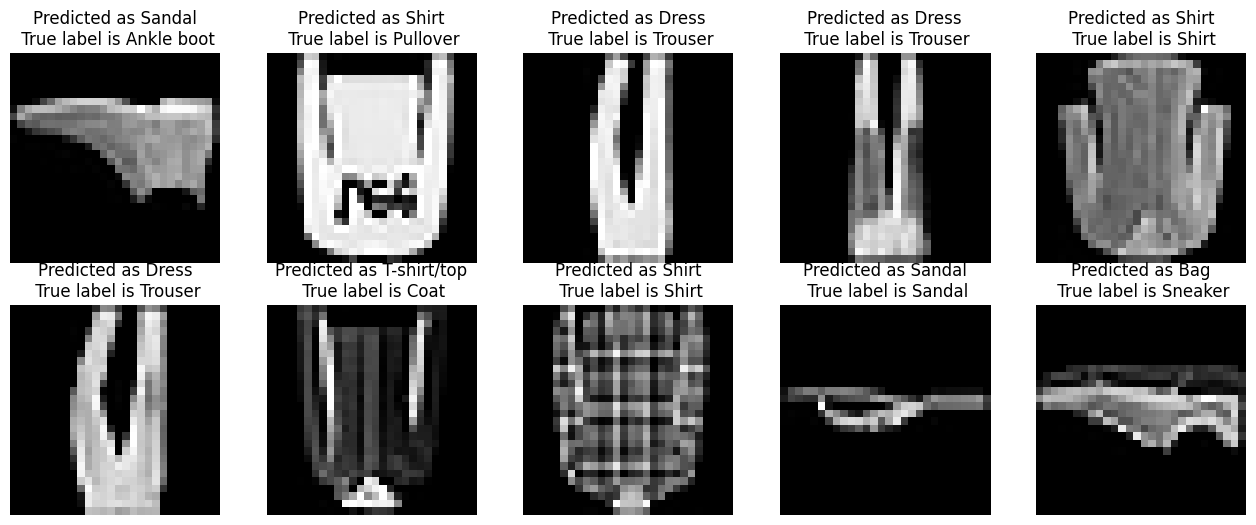

In [13]:
with torch.no_grad():

    data, target = next(iter(val_loader))
    data, target = data.to(device), target.to(device)
    # We flip horizontally the images
    data = data.flip(2)

    output = model(data)
    predictions = np.argmax(output.cpu().numpy(), axis=1).tolist()
    true = target.cpu().numpy().tolist()

    plt.figure(figsize=(16, 6))

    print("Correctly predicted: {}%".format(100*sum(p == t for p, t in zip(predictions, true))/len(predictions)) )

    for i in range(10):
        plt.subplot(2, 5, i + 1)
        image = data[i,...].cpu().numpy().reshape((28,28))
        plt.imshow(image, cmap="gray")
        plt.axis('off')
        plt.title('Predicted as {}\n True label is {}'.format(val_set.classes[predictions[i]], val_set.classes[true[i]], ))


As we can see, the accuracy is really affected by this transform, since the model has not been trained on this type of data.

In some cases, the prediction is right, which mean that the characteristics of the image that have been took into account to determine the class are possibly less sensible to this kind of flip (shirt for example).

On the other hand, some objects are drastically modified by the flip transform. This leads, of course, to bad results.

# Visualising Filters

One thing that would be interesting to visualise is the weights of the filters. To do so, we just need to access the weights of the convolutional layer of interest, and turn them into images. Here's an example for the first convolutional layer.

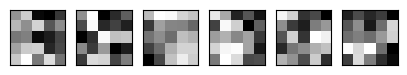

In [14]:
weight = model.conv1.weight.data.cpu().numpy()

# Display the filters
fig, ax = plt.subplots(1, weight.shape[0], figsize=(5, 5))

for i in range(weight.shape[0]):
    ax[i].imshow(weight[i, 0], cmap='gray') # show the first (and only) channel weights
    ax[i].axes.get_xaxis().set_visible(False)
    ax[i].axes.get_yaxis().set_visible(False)

# Visualising Activation Maps

Another thing would be to visualise the activations of a convolutional layer for a specific image when it goes through the model. To do so, we need to somehow capture the output of the convolutional layer during the forward pass. This can be done with the function `nn.Conv2d.register_forward_hook()`. This function accepts as argument a callback function that will be called by the model when the forward pass takes place.

See some more information about this function below:

In [15]:
nn.Conv2d.register_forward_hook??

To try this out, we will define by hand a toy model that does edge detection, as well as a couple of images to apply it on

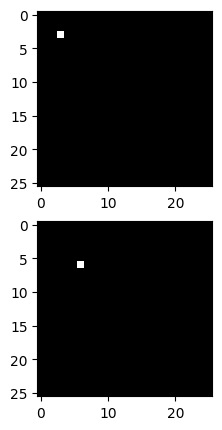

In [16]:
simpleEdgeDetector = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3)

# Define a vertical edge detector filter
simpleEdgeDetector.weight.data[0, 0] = torch.tensor([  [1., 0., -1.],
                                                   [1., 0., -1.],
                                                   [1., 0., -1.]])

# Define an horizontal edge detector filter
simpleEdgeDetector.weight.data[1, 0] = torch.tensor([  [1., 1., 1.],
                                                   [0., 0., 0.],
                                                   [-1., -1., -1.]])
# Define the biases
simpleEdgeDetector.bias.data = torch.zeros(2)

simpleEdgeDetector = simpleEdgeDetector.to(device)


fakeImageBatch = torch.zeros(2, 1, 26, 26) # create a batch of two black images of (10, 10)
fakeImageBatch[0,0,3,3] = 1 # Paint white pixel (3, 3)
fakeImageBatch[1,0,6,6] = 1 # Paint white pixel (6, 6)

# Show the images
fig, ax = plt.subplots(2, 1, figsize=(5, 5))
ax[0].imshow(fakeImageBatch[0,0], cmap='gray')
ax[1].imshow(fakeImageBatch[1,0], cmap='gray')

Let's also define some helper functions to plot a grid of activation maps given the output of a convolution layer.

In [17]:
def showImage(img, ax):
    # Convert the tensor to numpy
    out = img.numpy()
    # Bring to the 0-255 range
    out = out - out.min()
    out = out / out.max()
    out = out * 255
    out = out.astype('uint8')
    # Plot image
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)
    ax.imshow(out, cmap='gray')

def showConvMap(conv_map):
    # Create a grid of images
    h = conv_map.shape[0] # = number of images in the batch
    w = conv_map.shape[1] # = number of activation maps per image
    fig, ax = plt.subplots(h, w, figsize=(10, 10))

    # Plot activation maps
    for i in range(conv_map.shape[0]):
        for j in range(conv_map.shape[1]):
            showImage(conv_map[i][j], ax[i, j])

    fig.tight_layout()

Now we can define our hook function, which just calls `showConvMap()` to plot the output activation maps for all the images of our batch and all the filters of this layer.

Output shape: torch.Size([2, 2, 24, 24])


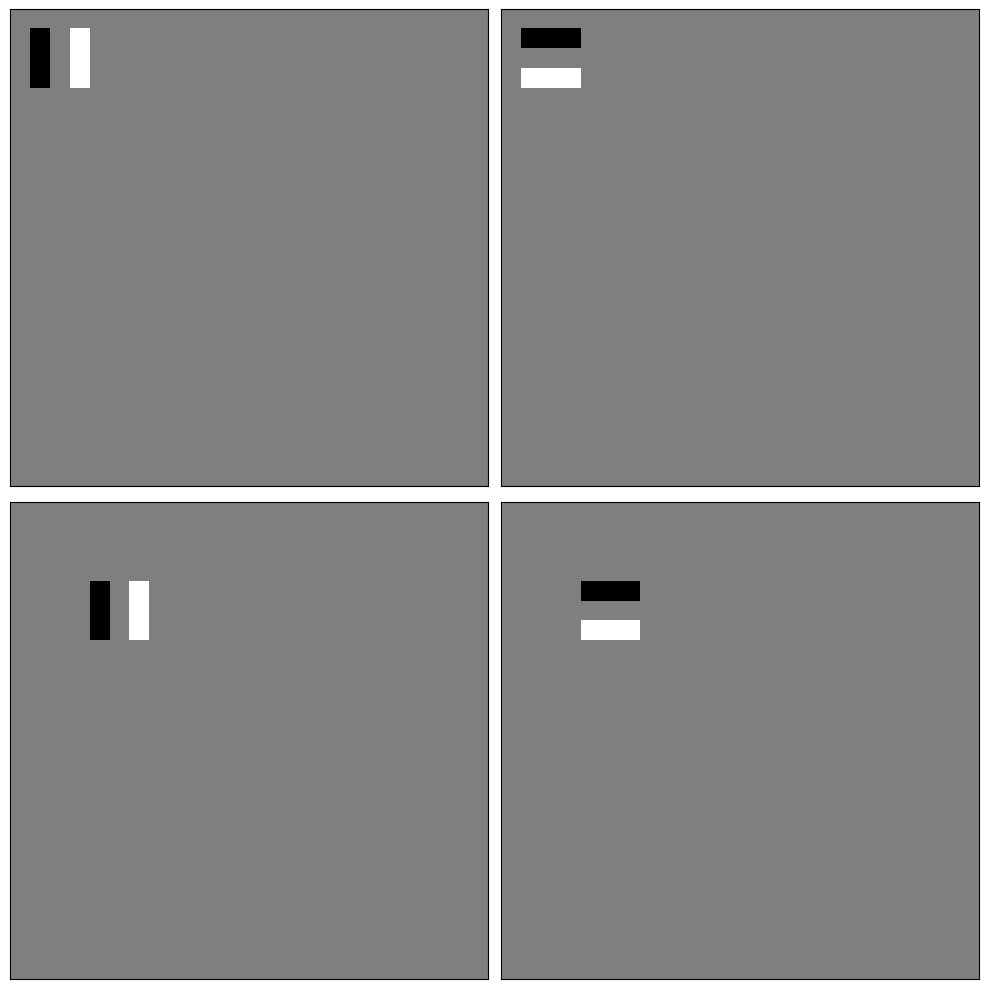

In [18]:
def hook_ShowOutput(module, input, output):
    print("Output shape:", output.shape)
    showConvMap(output.cpu())

fakeImageBatch = fakeImageBatch.to(device)

with torch.no_grad():
    handle = simpleEdgeDetector.register_forward_hook(hook_ShowOutput)
    embed = simpleEdgeDetector(fakeImageBatch)
    handle.remove()

<br>
<span style="color:blue">
    
**Exercise 5**: Visualize the feature (activation) maps of the first and last convolutional layers of our CNN model for 10 images of your validation set. Use the code provided before as the basis for your visualisation. What conclusions can you draw?
    
</span>

Output shape: torch.Size([10, 6, 24, 24])


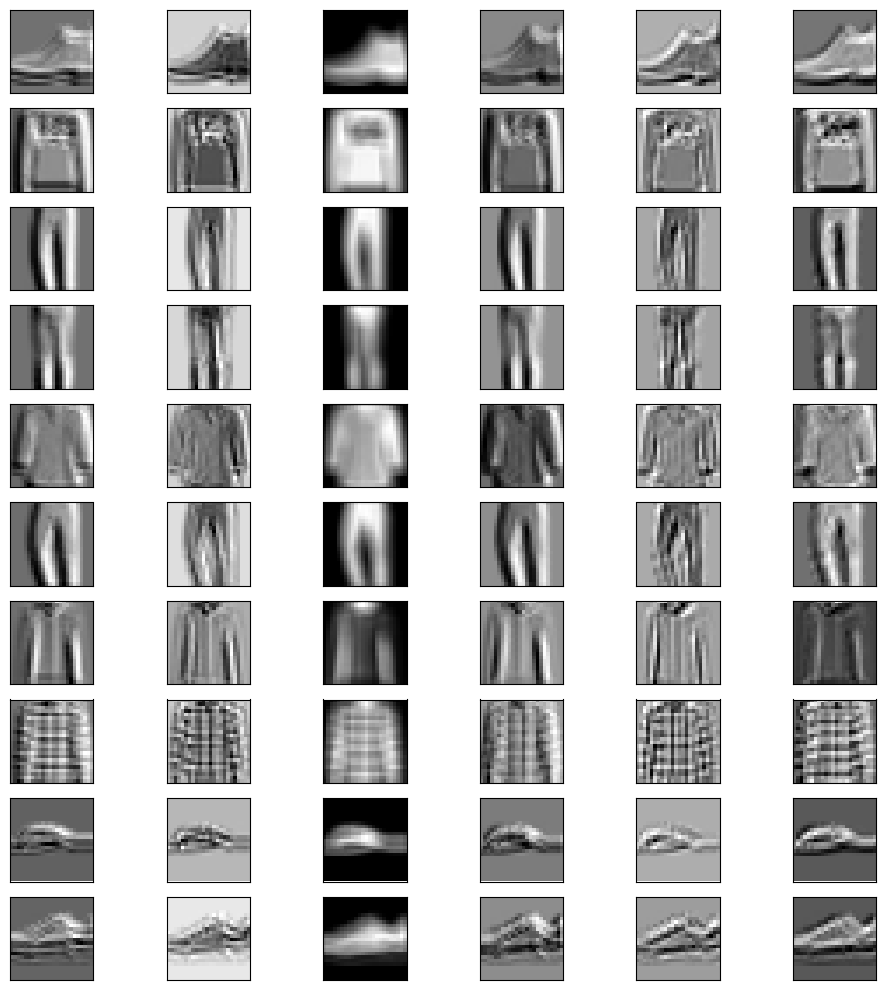

In [19]:
data, target = next(iter(val_loader))
data, target = data[:10].to(device), target[:10].to(device)

with torch.no_grad():
    handle = model.conv1.register_forward_hook(hook_ShowOutput)
    embed = model(data)
    handle.remove()

With this first result, we can see that the objects are a bit better localised : we can see a greater contrast between the object and its background. In other words, the contour of the objects is better defined than before.

But, we can still see which object is present on each picture.

Output shape: torch.Size([10, 6, 8, 8])


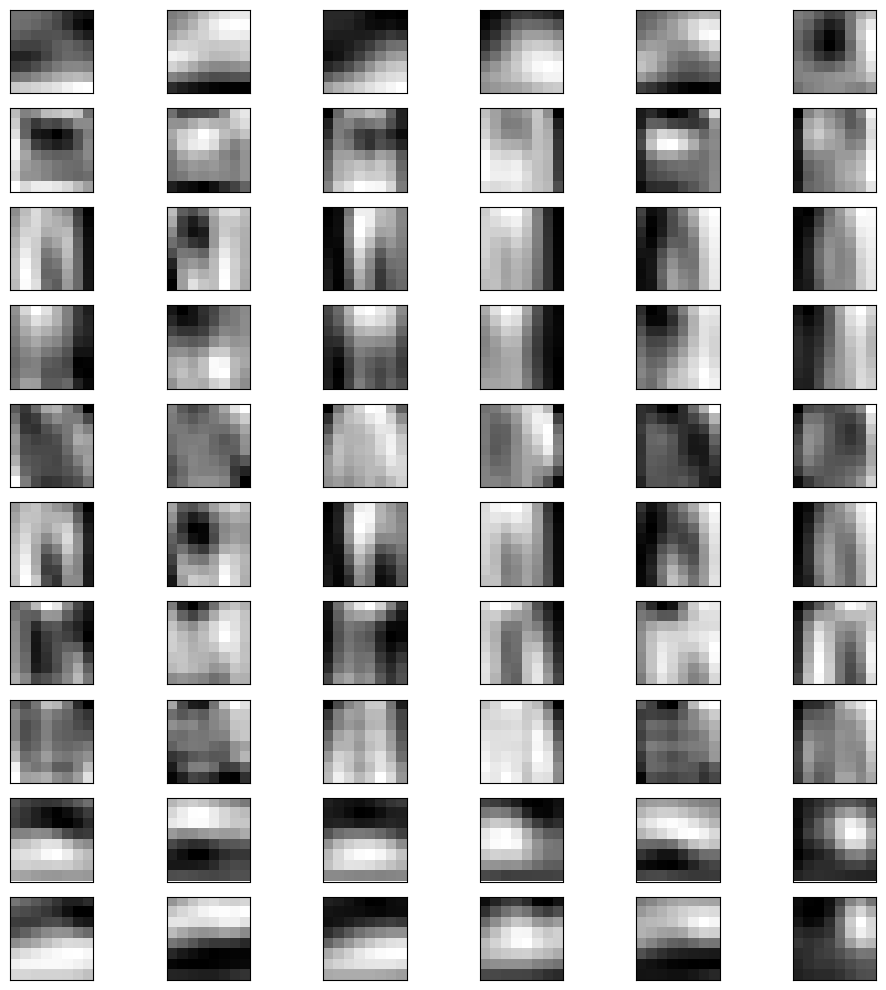

In [21]:
with torch.no_grad():
    handle = model.conv2.register_forward_hook(hook_ShowOutput)
    embed = model(data)
    handle.remove()

Now, with the second convolutional layer, we can observe that the activation maps are more localised on a special part of the objects. Here we cannot guess from which object the picture is from.

We can observe here how the network selects special parts of the objects to recognise them : we went from a general to a particular view of the objects.